# Comparative Analysis of Machine Learning and Deep Learning (LSTM) for Stock Market Prediction
**Authors: Danish Awasthi and Mayank Gupta**  
*Chitkara University Institute of Engineering and Technology, Chitkara University, Rajpura, Punjab, India*

---
This notebook implements and compares:
- **ML Models:** Linear Regression, SVM, Random Forest, Decision Tree, Gradient Boosting, KNN
- **DL Model:** LSTM (Long Short-Term Memory)

**Dataset:** Apple Inc. (AAPL) stock data from Yahoo Finance (2015–2024)

## 1. Install & Import Libraries

In [7]:
# Install required libraries
!pip3 install yfinance scikit-learn tensorflow keras matplotlib seaborn pandas numpy --quiet

You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Yahoo Finance
import yfinance as yf

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid')

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Matplotlib is building the font cache; this may take a moment.


✅ All libraries imported successfully!
TensorFlow version: 2.20.0


## 2. Data Collection — Apple Inc. (AAPL) 2015–2024

In [9]:
# Download AAPL stock data
ticker = 'AAPL'
df = yf.download(ticker, start='2015-01-01', end='2024-12-31', progress=False)
df.reset_index(inplace=True)

# Flatten MultiIndex columns if present
if isinstance(df.columns, pd.MultiIndex):
    df.columns = [col[0] if col[1] == '' else col[0] for col in df.columns]

print(f"Dataset Shape: {df.shape}")
print(f"Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (2515, 6)
Date Range: 2015-01-02 to 2024-12-30

Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']


,Date,Close,High,Low,Open,Volume
0,2015-01-02,24.214886,24.682218,23.776346,24.671143,212818400
1,2015-01-05,23.532724,24.064287,23.346678,23.984553,257142000
2,2015-01-06,23.534927,23.794064,23.173907,23.596943,263188400
3,2015-01-07,23.864948,23.964616,23.632389,23.743131,160423600
4,2015-01-08,24.781891,24.839477,24.075355,24.192743,237458000


## 3. Exploratory Data Analysis (EDA)

In [10]:
# Summary statistics
print("=== DATASET STATISTICS ===")
print(df[['Open','High','Low','Close','Volume']].describe().round(2))
print(f"\nMissing Values:\n{df.isnull().sum()}")

=== DATASET STATISTICS ===
          Open     High      Low    Close        Volume
count  2515.00  2515.00  2515.00  2515.00  2.515000e+03
mean     93.62    94.62    92.70    93.71  1.171162e+08
std      65.24    65.91    64.63    65.32  6.839222e+07
min      20.51    20.89    20.39    20.58  2.323470e+07
25%      35.20    35.57    34.81    35.17  7.108655e+07
50%      64.07    64.66    63.51    64.31  1.003845e+08
75%     149.86   151.81   148.07   150.08  1.426222e+08
max     256.79   258.69   256.23   257.61  6.488252e+08

Missing Values:
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


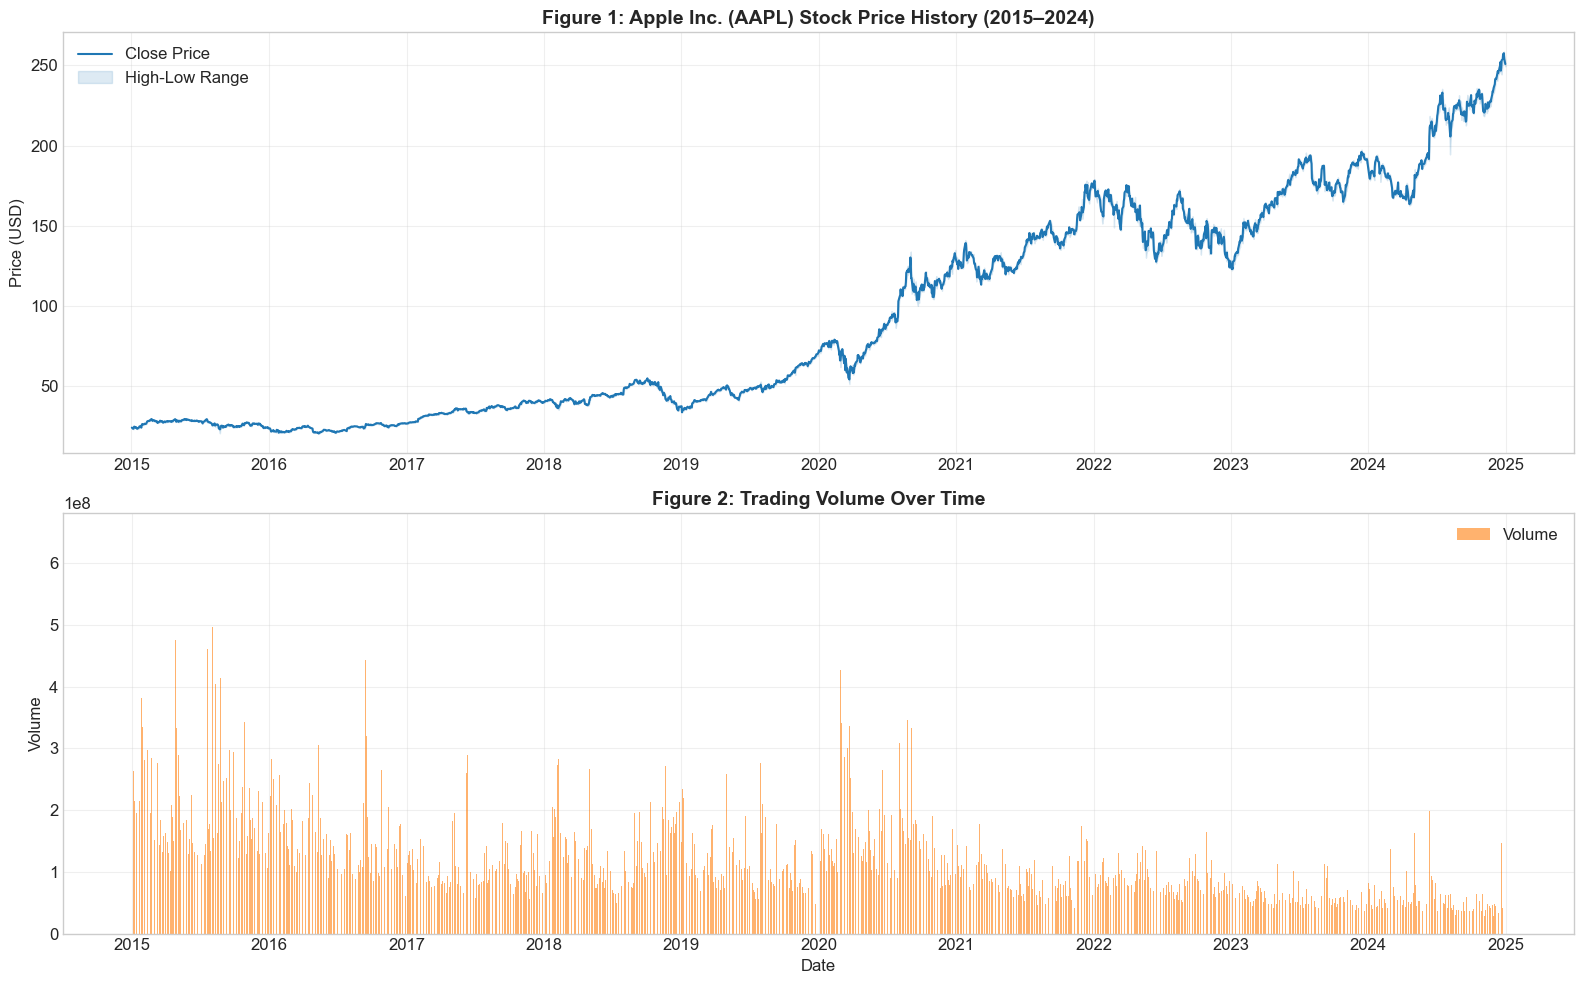

Figure 1 & 2 saved.


In [11]:
# Figure 1: Stock Price History
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(df['Date'], df['Close'], color='#1f77b4', linewidth=1.5, label='Close Price')
axes[0].fill_between(df['Date'], df['Low'], df['High'], alpha=0.15, color='#1f77b4', label='High-Low Range')
axes[0].set_title('Figure 1: Apple Inc. (AAPL) Stock Price History (2015–2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Volume
axes[1].bar(df['Date'], df['Volume'], color='#ff7f0e', alpha=0.6, label='Volume')
axes[1].set_title('Figure 2: Trading Volume Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('fig1_stock_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 1 & 2 saved.")

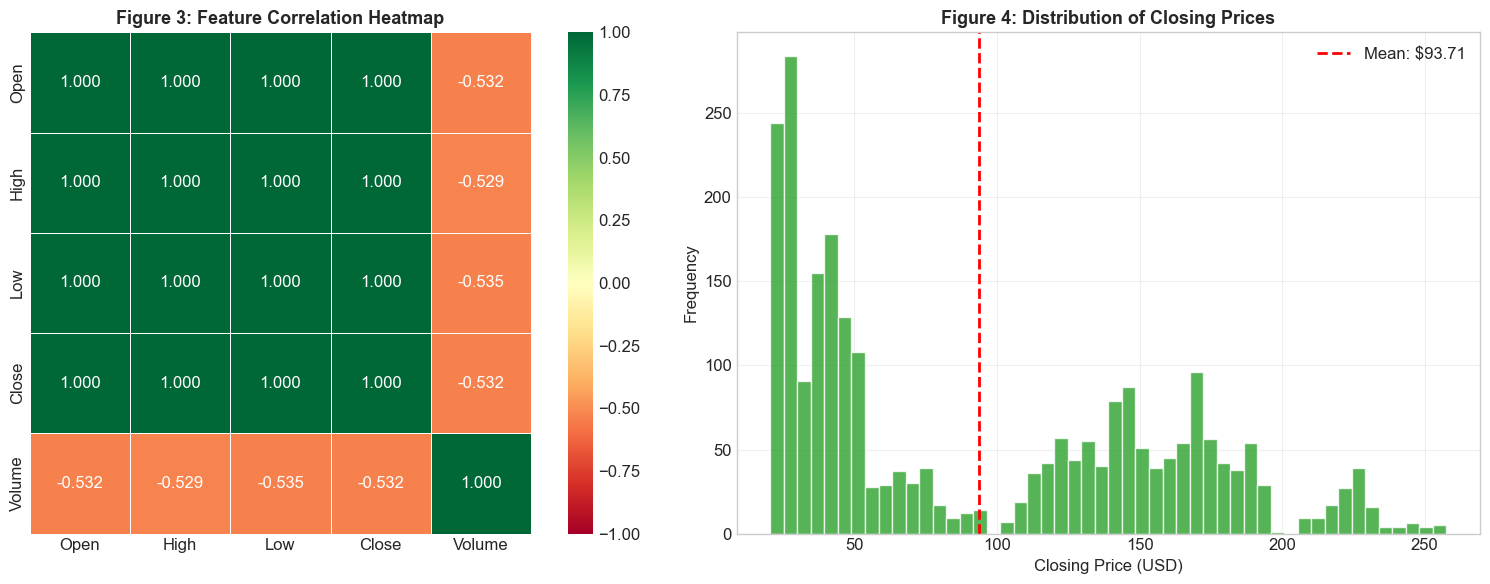

Figure 3 & 4 saved.


In [12]:
# Figure 3: Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation
corr_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
corr = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
            linewidths=0.5, square=True, vmin=-1, vmax=1)
axes[0].set_title('Figure 3: Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# Distribution of Close prices
axes[1].hist(df['Close'], bins=50, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[1].axvline(df['Close'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["Close"].mean():.2f}')
axes[1].set_title('Figure 4: Distribution of Closing Prices', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Closing Price (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 & 4 saved.")

## 4. Feature Engineering

In [13]:
def add_technical_indicators(df):
    """Add technical indicators as features."""
    df = df.copy()
    
    # Moving Averages
    df['MA_7']   = df['Close'].rolling(window=7).mean()
    df['MA_20']  = df['Close'].rolling(window=20).mean()
    df['MA_50']  = df['Close'].rolling(window=50).mean()
    
    # Exponential Moving Average
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    
    # MACD
    df['MACD']   = df['EMA_12'] - df['EMA_26']
    
    # RSI (14-period)
    delta = df['Close'].diff()
    gain  = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs    = gain / (loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))
    
    # Bollinger Bands
    df['BB_middle'] = df['Close'].rolling(window=20).mean()
    df['BB_std']    = df['Close'].rolling(window=20).std()
    df['BB_upper']  = df['BB_middle'] + 2 * df['BB_std']
    df['BB_lower']  = df['BB_middle'] - 2 * df['BB_std']
    
    # Price Rate of Change
    df['ROC']       = df['Close'].pct_change(periods=5) * 100
    
    # Volatility
    df['Volatility'] = df['Close'].rolling(window=20).std()
    
    # Day, Month, Year
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    df['Month']     = df['Date'].dt.month
    df['Year']      = df['Date'].dt.year
    
    # Target: next day closing price
    df['Target'] = df['Close'].shift(-1)
    
    df.dropna(inplace=True)
    return df

df_fe = add_technical_indicators(df)
print(f"Shape after feature engineering: {df_fe.shape}")
print(f"Features: {[c for c in df_fe.columns if c not in ['Date','Target']]}")

Shape after feature engineering: (2465, 23)
Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_7', 'MA_20', 'MA_50', 'EMA_12', 'EMA_26', 'MACD', 'RSI', 'BB_middle', 'BB_std', 'BB_upper', 'BB_lower', 'ROC', 'Volatility', 'DayOfWeek', 'Month', 'Year']


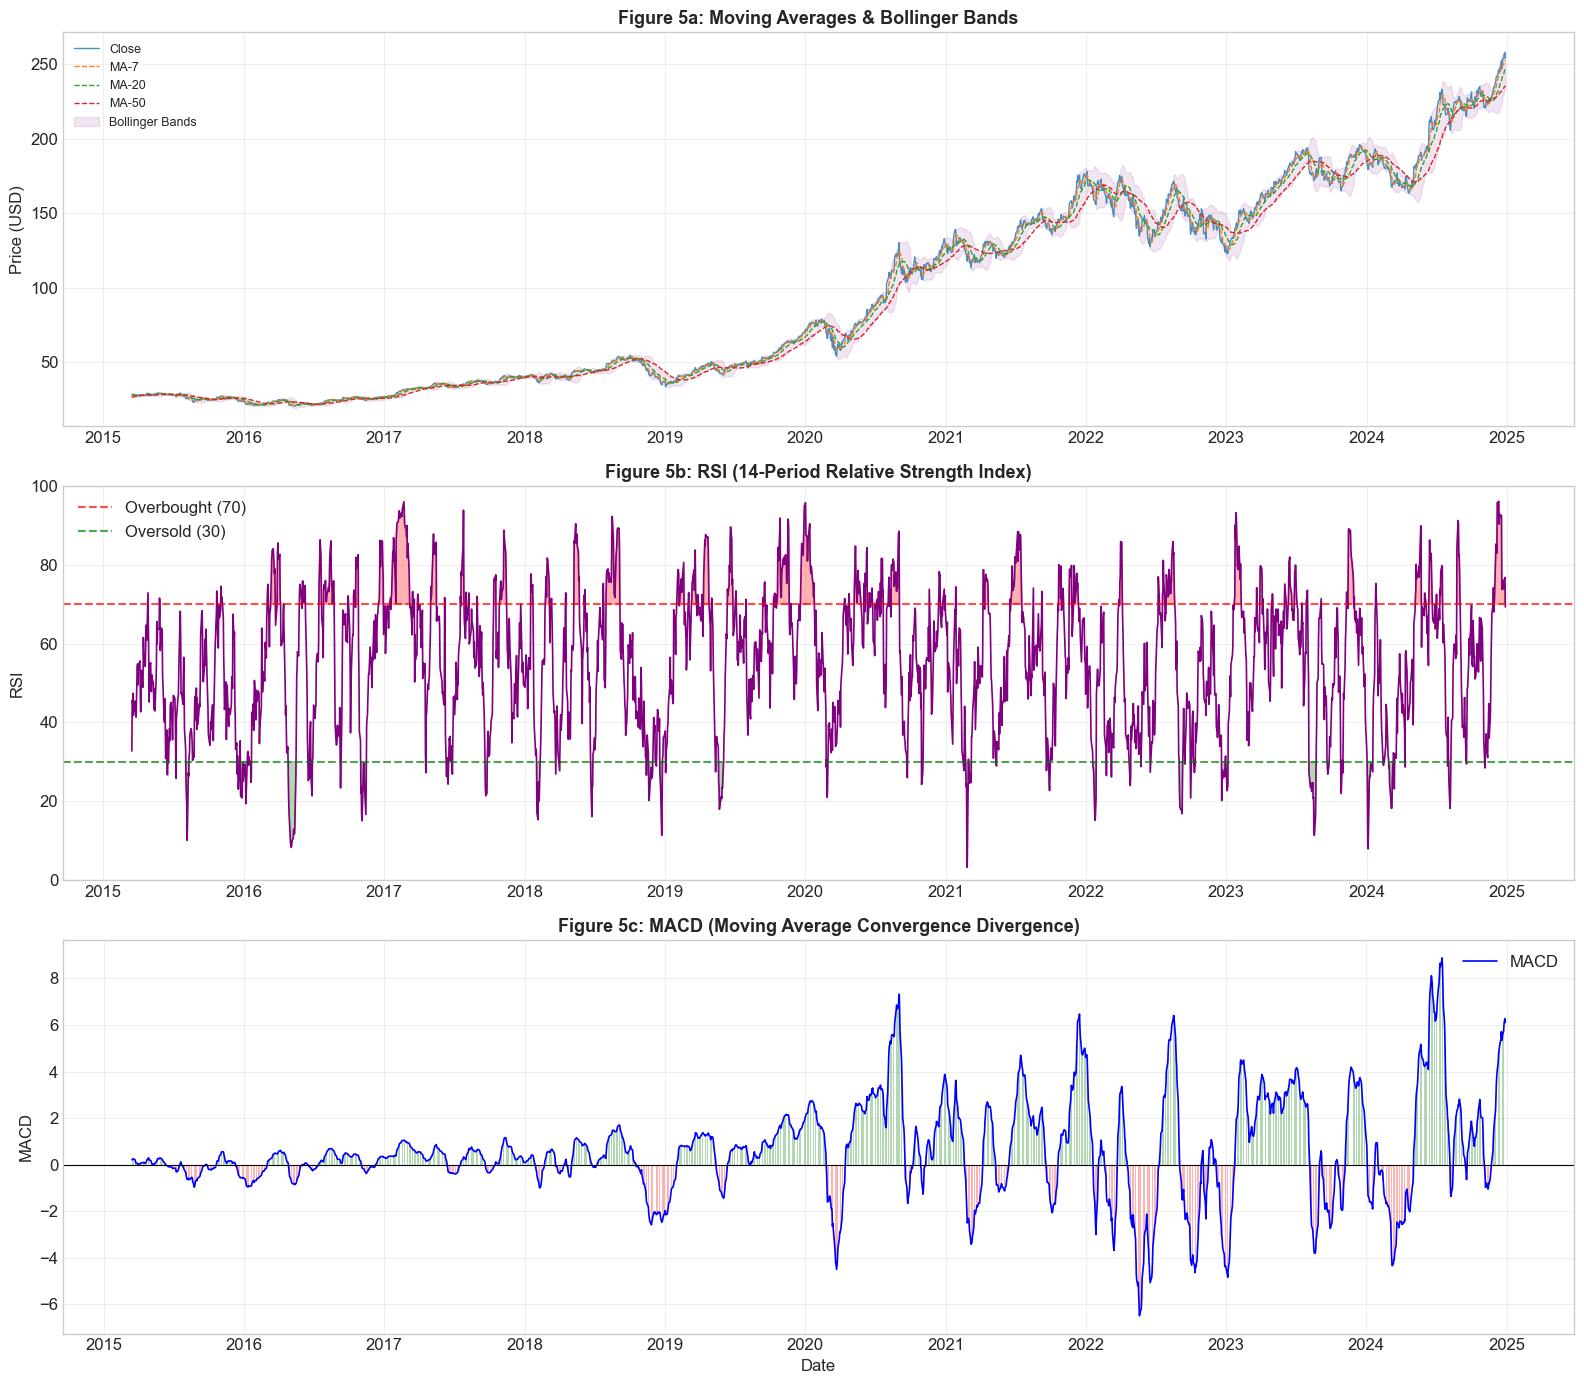

Figure 5 saved.


In [14]:
# Figure 5: Technical Indicators Visualization
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Moving averages
axes[0].plot(df_fe['Date'], df_fe['Close'], label='Close', alpha=0.8, linewidth=1)
axes[0].plot(df_fe['Date'], df_fe['MA_7'],  label='MA-7',  linestyle='--', linewidth=1)
axes[0].plot(df_fe['Date'], df_fe['MA_20'], label='MA-20', linestyle='--', linewidth=1)
axes[0].plot(df_fe['Date'], df_fe['MA_50'], label='MA-50', linestyle='--', linewidth=1)
axes[0].fill_between(df_fe['Date'], df_fe['BB_lower'], df_fe['BB_upper'], alpha=0.1, color='purple', label='Bollinger Bands')
axes[0].set_title('Figure 5a: Moving Averages & Bollinger Bands', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(loc='upper left', fontsize=9)

# RSI
axes[1].plot(df_fe['Date'], df_fe['RSI'], color='purple', linewidth=1.2)
axes[1].axhline(70, color='red',   linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(df_fe['Date'], 30, df_fe['RSI'], where=(df_fe['RSI'] < 30), alpha=0.3, color='green')
axes[1].fill_between(df_fe['Date'], 70, df_fe['RSI'], where=(df_fe['RSI'] > 70), alpha=0.3, color='red')
axes[1].set_title('Figure 5b: RSI (14-Period Relative Strength Index)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend()

# MACD
axes[2].plot(df_fe['Date'], df_fe['MACD'], color='blue', linewidth=1.2, label='MACD')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].bar(df_fe['Date'], df_fe['MACD'], alpha=0.3, color=np.where(df_fe['MACD']>=0,'green','red'))
axes[2].set_title('Figure 5c: MACD (Moving Average Convergence Divergence)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('MACD')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig5_technical_indicators.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 5 saved.")

## 5. Data Preparation for ML Models

In [15]:
# Feature selection for ML models
ML_FEATURES = ['Open','High','Low','Close','Volume',
               'MA_7','MA_20','MA_50','EMA_12','EMA_26',
               'MACD','RSI','BB_upper','BB_lower','ROC',
               'Volatility','DayOfWeek','Month']

X = df_fe[ML_FEATURES].values
y = df_fe['Target'].values

# Scale features
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Train-test split (80:20)
split_idx = int(len(X_scaled) * 0.80)
X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y_scaled[:split_idx], y_scaled[split_idx:]

# Keep dates for plotting
dates_test = df_fe['Date'].values[split_idx:]

print(f"Training samples : {len(X_train):,}")
print(f"Testing samples  : {len(X_test):,}")
print(f"Features         : {X_train.shape[1]}")
print(f"Test period      : {pd.to_datetime(dates_test[0]).date()} → {pd.to_datetime(dates_test[-1]).date()}")

Training samples : 1,972
Testing samples  : 493
Features         : 18
Test period      : 2023-01-12 → 2024-12-27


## 6. Train ML Models

In [16]:
def evaluate_model(name, y_true_scaled, y_pred_scaled):
    """Inverse transform and compute metrics."""
    y_true = scaler_y.inverse_transform(y_true_scaled.reshape(-1,1)).ravel()
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1,1)).ravel()
    
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    
    print(f"  {name:<25} MAE={mae:6.2f}  RMSE={rmse:6.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return {'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'R2': round(r2,4), 'MAPE(%)': round(mape,2),
            'y_true': y_true, 'y_pred': y_pred}

# Define ML models
ml_models = {
    'Linear Regression':    LinearRegression(),
    'Decision Tree':        DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest':        RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':    GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=42),
    'SVM (SVR)':            SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1),
    'KNN':                  KNeighborsRegressor(n_neighbors=7)
}

print("Training and evaluating ML models...\n")
print(f"  {'Model':<25} {'MAE':>8}  {'RMSE':>7}  {'R²':>7}  {'MAPE':>8}")
print("  " + "-"*65)

ml_results = {}
for name, model in ml_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    ml_results[name] = evaluate_model(name, y_test, y_pred)

print("\n✅ All ML models trained successfully!")

Training and evaluating ML models...

  Model                          MAE     RMSE       R²      MAPE
  -----------------------------------------------------------------
  Linear Regression         MAE=  1.91  RMSE=  2.59  R²=0.9908  MAPE=1.02%
  Decision Tree             MAE= 19.42  RMSE= 28.80  R²=-0.1311  MAPE=9.07%
  Random Forest             MAE= 20.65  RMSE= 30.44  R²=-0.2639  MAPE=9.63%
  Gradient Boosting         MAE= 22.75  RMSE= 32.49  R²=-0.4400  MAPE=10.68%
  SVM (SVR)                 MAE= 30.28  RMSE= 34.26  R²=-0.6010  MAPE=15.22%
  KNN                       MAE= 27.69  RMSE= 34.40  R²=-0.6143  MAPE=13.57%

✅ All ML models trained successfully!


## 7. LSTM Deep Learning Model

In [17]:
# Prepare data for LSTM (sequence-based)
LOOKBACK = 60  # Use 60 previous days

# Use only Close price for LSTM (classic approach)
close_data = df_fe['Close'].values.reshape(-1, 1)
scaler_lstm = MinMaxScaler()
close_scaled = scaler_lstm.fit_transform(close_data)

def create_sequences(data, lookback):
    X_seq, y_seq = [], []
    for i in range(lookback, len(data)):
        X_seq.append(data[i-lookback:i, 0])
        y_seq.append(data[i, 0])
    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(close_scaled, LOOKBACK)
X_seq = X_seq.reshape(X_seq.shape[0], X_seq.shape[1], 1)

# Split LSTM data (80:20, chronological)
split_lstm = int(len(X_seq) * 0.80)
X_lstm_train, X_lstm_test = X_seq[:split_lstm], X_seq[split_lstm:]
y_lstm_train, y_lstm_test = y_seq[:split_lstm], y_seq[split_lstm:]

print(f"LSTM Training sequences : {len(X_lstm_train):,}")
print(f"LSTM Testing sequences  : {len(X_lstm_test):,}")
print(f"Sequence shape          : {X_lstm_train.shape}")

LSTM Training sequences : 1,924
LSTM Testing sequences  : 481
Sequence shape          : (1924, 60, 1)


In [18]:
# Build LSTM Model
tf.random.set_seed(42)

lstm_model = Sequential([
    Input(shape=(LOOKBACK, 1)),
    LSTM(units=128, return_sequences=True),
    Dropout(0.2),
    LSTM(units=64, return_sequences=True),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                   loss='mean_squared_error',
                   metrics=['mae'])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Train LSTM
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_lstm_train, y_lstm_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0131 - mae: 0.0671 - val_loss: 0.0020 - val_mae: 0.0374
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0012 - mae: 0.0210 - val_loss: 0.0013 - val_mae: 0.0309
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0011 - mae: 0.0199 - val_loss: 0.0017 - val_mae: 0.0331
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9.1250e-04 - mae: 0.0190 - val_loss: 0.0010 - val_mae: 0.0271
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 9.9871e-04 - mae: 0.0198 - val_loss: 9.5668e-04 - val_mae: 0.0262
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 7.2067e-04 - mae: 0.0169 - val_loss: 0.0017 - val_mae: 0.0335
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.7600e-04 - mae: 0.0196 - val_loss: 0.0017 - val_mae: 0.0333
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.0295e-04 - mae: 0.0173 - val_loss: 0.0029 - val_mae: 0.0464
Epoch 9/100
55/55 ━━━━━━━━━━━━━━

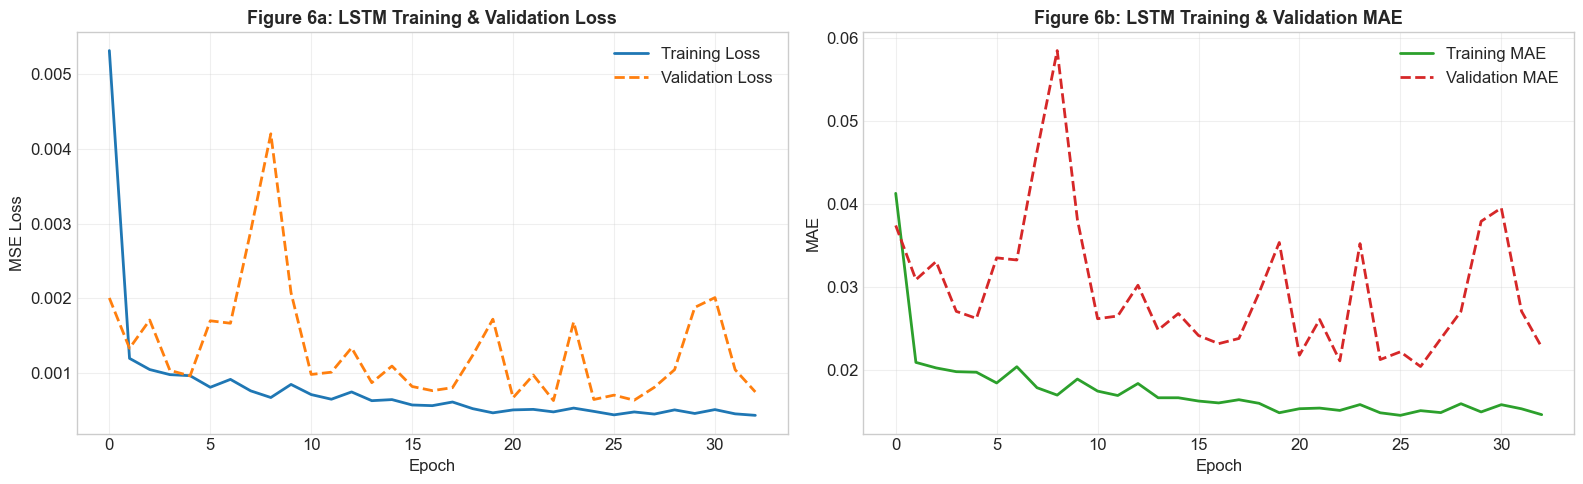

Figure 6 saved.


In [20]:
# Figure 6: LSTM Training History
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history.history['loss'],     label='Training Loss', color='#1f77b4', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e', linewidth=2, linestyle='--')
axes[0].set_title('Figure 6a: LSTM Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Training MAE', color='#2ca02c', linewidth=2)
axes[1].plot(history.history['val_mae'], label='Validation MAE', color='#d62728', linewidth=2, linestyle='--')
axes[1].set_title('Figure 6b: LSTM Training & Validation MAE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig6_lstm_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 6 saved.")

In [21]:
# Evaluate LSTM
lstm_pred_scaled = lstm_model.predict(X_lstm_test).ravel()
y_lstm_true_orig = scaler_lstm.inverse_transform(y_lstm_test.reshape(-1,1)).ravel()
y_lstm_pred_orig = scaler_lstm.inverse_transform(lstm_pred_scaled.reshape(-1,1)).ravel()

lstm_mae  = mean_absolute_error(y_lstm_true_orig, y_lstm_pred_orig)
lstm_rmse = np.sqrt(mean_squared_error(y_lstm_true_orig, y_lstm_pred_orig))
lstm_r2   = r2_score(y_lstm_true_orig, y_lstm_pred_orig)
lstm_mape = np.mean(np.abs((y_lstm_true_orig - y_lstm_pred_orig) / (y_lstm_true_orig + 1e-10))) * 100

print("=== LSTM EVALUATION ===")
print(f"  MAE  : {lstm_mae:.2f}")
print(f"  RMSE : {lstm_rmse:.2f}")
print(f"  R²   : {lstm_r2:.4f}")
print(f"  MAPE : {lstm_mape:.2f}%")

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
=== LSTM EVALUATION ===
  MAE  : 8.12
  RMSE : 10.15
  R²   : 0.8489
  MAPE : 4.03%


## 8. Results & Comparative Analysis

In [22]:
# Build full results table
results_data = []
for name, res in ml_results.items():
    results_data.append({'Model': name, 'Type': 'ML',
                         'MAE': res['MAE'], 'RMSE': res['RMSE'],
                         'R²': res['R2'], 'MAPE(%)': res['MAPE(%)']})

results_data.append({'Model': 'LSTM', 'Type': 'DL',
                     'MAE': round(lstm_mae,2), 'RMSE': round(lstm_rmse,2),
                     'R²': round(lstm_r2,4), 'MAPE(%)': round(lstm_mape,2)})

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1
print("=== COMPARATIVE PERFORMANCE TABLE ===")
print(results_df[['Model','Type','MAE','RMSE','R²','MAPE(%)']].to_string())

=== COMPARATIVE PERFORMANCE TABLE ===
               Model Type    MAE   RMSE      R²  MAPE(%)
1  Linear Regression   ML   1.91   2.59  0.9908     1.02
2               LSTM   DL   8.12  10.15  0.8489     4.03
3      Decision Tree   ML  19.42  28.80 -0.1311     9.07
4      Random Forest   ML  20.65  30.44 -0.2639     9.63
5  Gradient Boosting   ML  22.75  32.49 -0.4400    10.68
6          SVM (SVR)   ML  30.28  34.26 -0.6010    15.22
7                KNN   ML  27.69  34.40 -0.6143    13.57


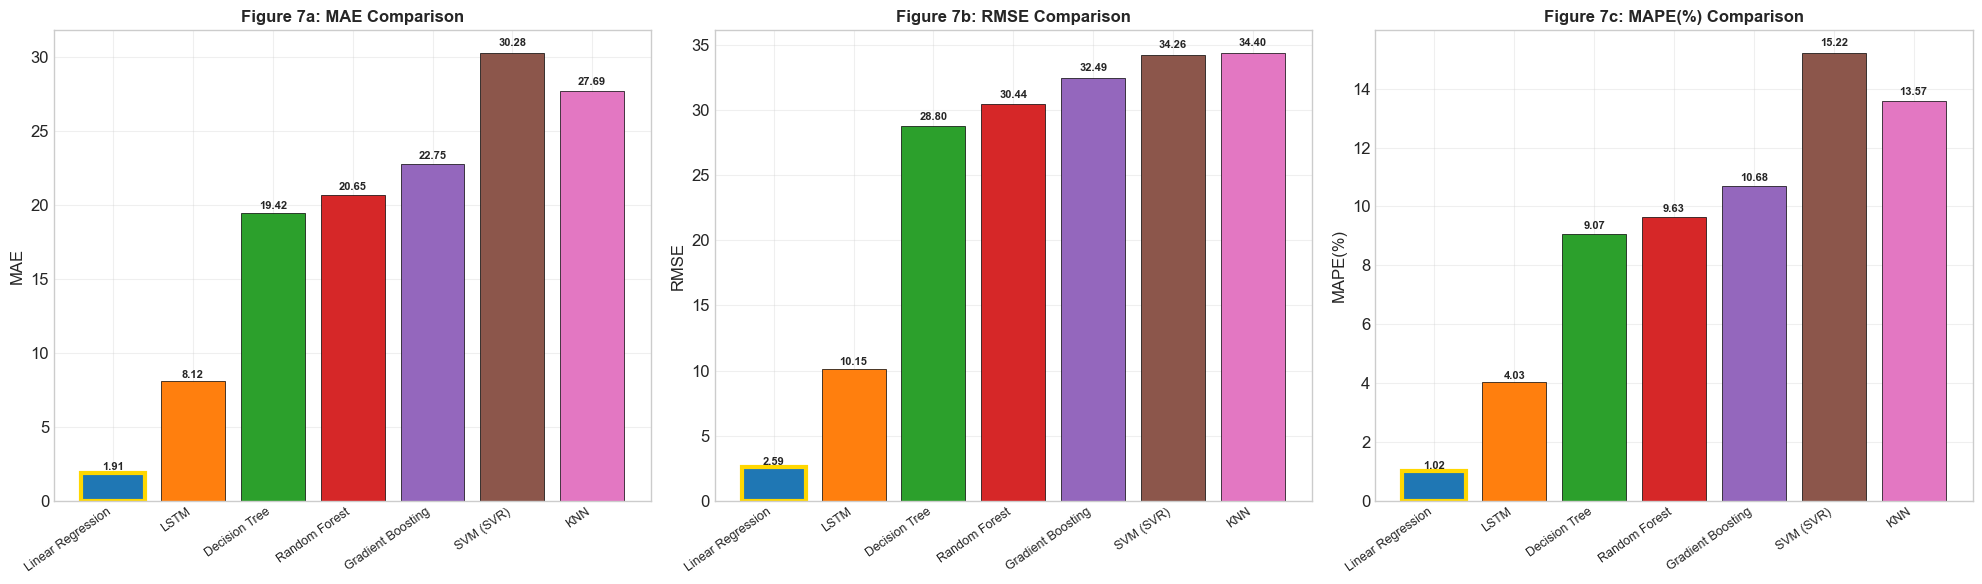

Figure 7 saved.


In [23]:
# Figure 7: Bar Chart Comparison
metrics = ['MAE', 'RMSE', 'MAPE(%)']
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b','#e377c2']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, metric in enumerate(metrics):
    bars = axes[i].bar(results_df['Model'], results_df[metric],
                       color=colors[:len(results_df)], edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'Figure 7{chr(97+i)}: {metric} Comparison', fontsize=12, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df['Model'], rotation=35, ha='right', fontsize=9)
    # Annotate
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01*bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    # Highlight best (min)
    best_idx = results_df[metric].idxmin() - 1
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.tight_layout()
plt.savefig('fig7_metric_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 7 saved.")

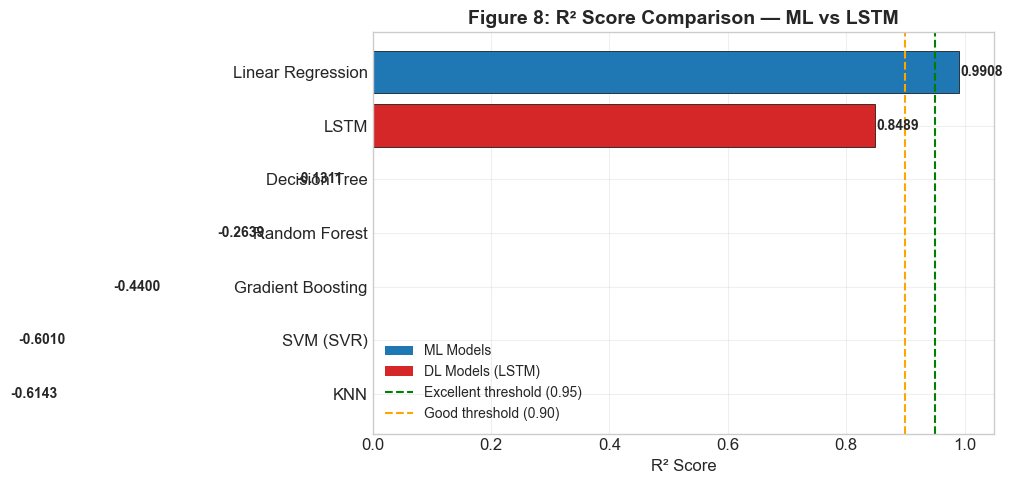

Figure 8 saved.


In [24]:
# Figure 8: R² Score Comparison
fig, ax = plt.subplots(figsize=(12, 5))

r2_sorted = results_df.sort_values('R²', ascending=True)
bar_colors = ['#d62728' if t == 'DL' else '#1f77b4' for t in r2_sorted['Type']]

bars = ax.barh(r2_sorted['Model'], r2_sorted['R²'], color=bar_colors, edgecolor='black', linewidth=0.5)
ax.axvline(x=0.95, color='green', linestyle='--', linewidth=1.5, label='Excellent threshold (0.95)')
ax.axvline(x=0.90, color='orange', linestyle='--', linewidth=1.5, label='Good threshold (0.90)')

for bar, val in zip(bars, r2_sorted['R²']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#1f77b4', label='ML Models'),
                   Patch(facecolor='#d62728', label='DL Models (LSTM)')]
ax.legend(handles=legend_elements + ax.get_lines(), fontsize=10)

ax.set_title('Figure 8: R² Score Comparison — ML vs LSTM', fontsize=14, fontweight='bold')
ax.set_xlabel('R² Score')
ax.set_xlim(0, 1.05)

plt.tight_layout()
plt.savefig('fig8_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 8 saved.")

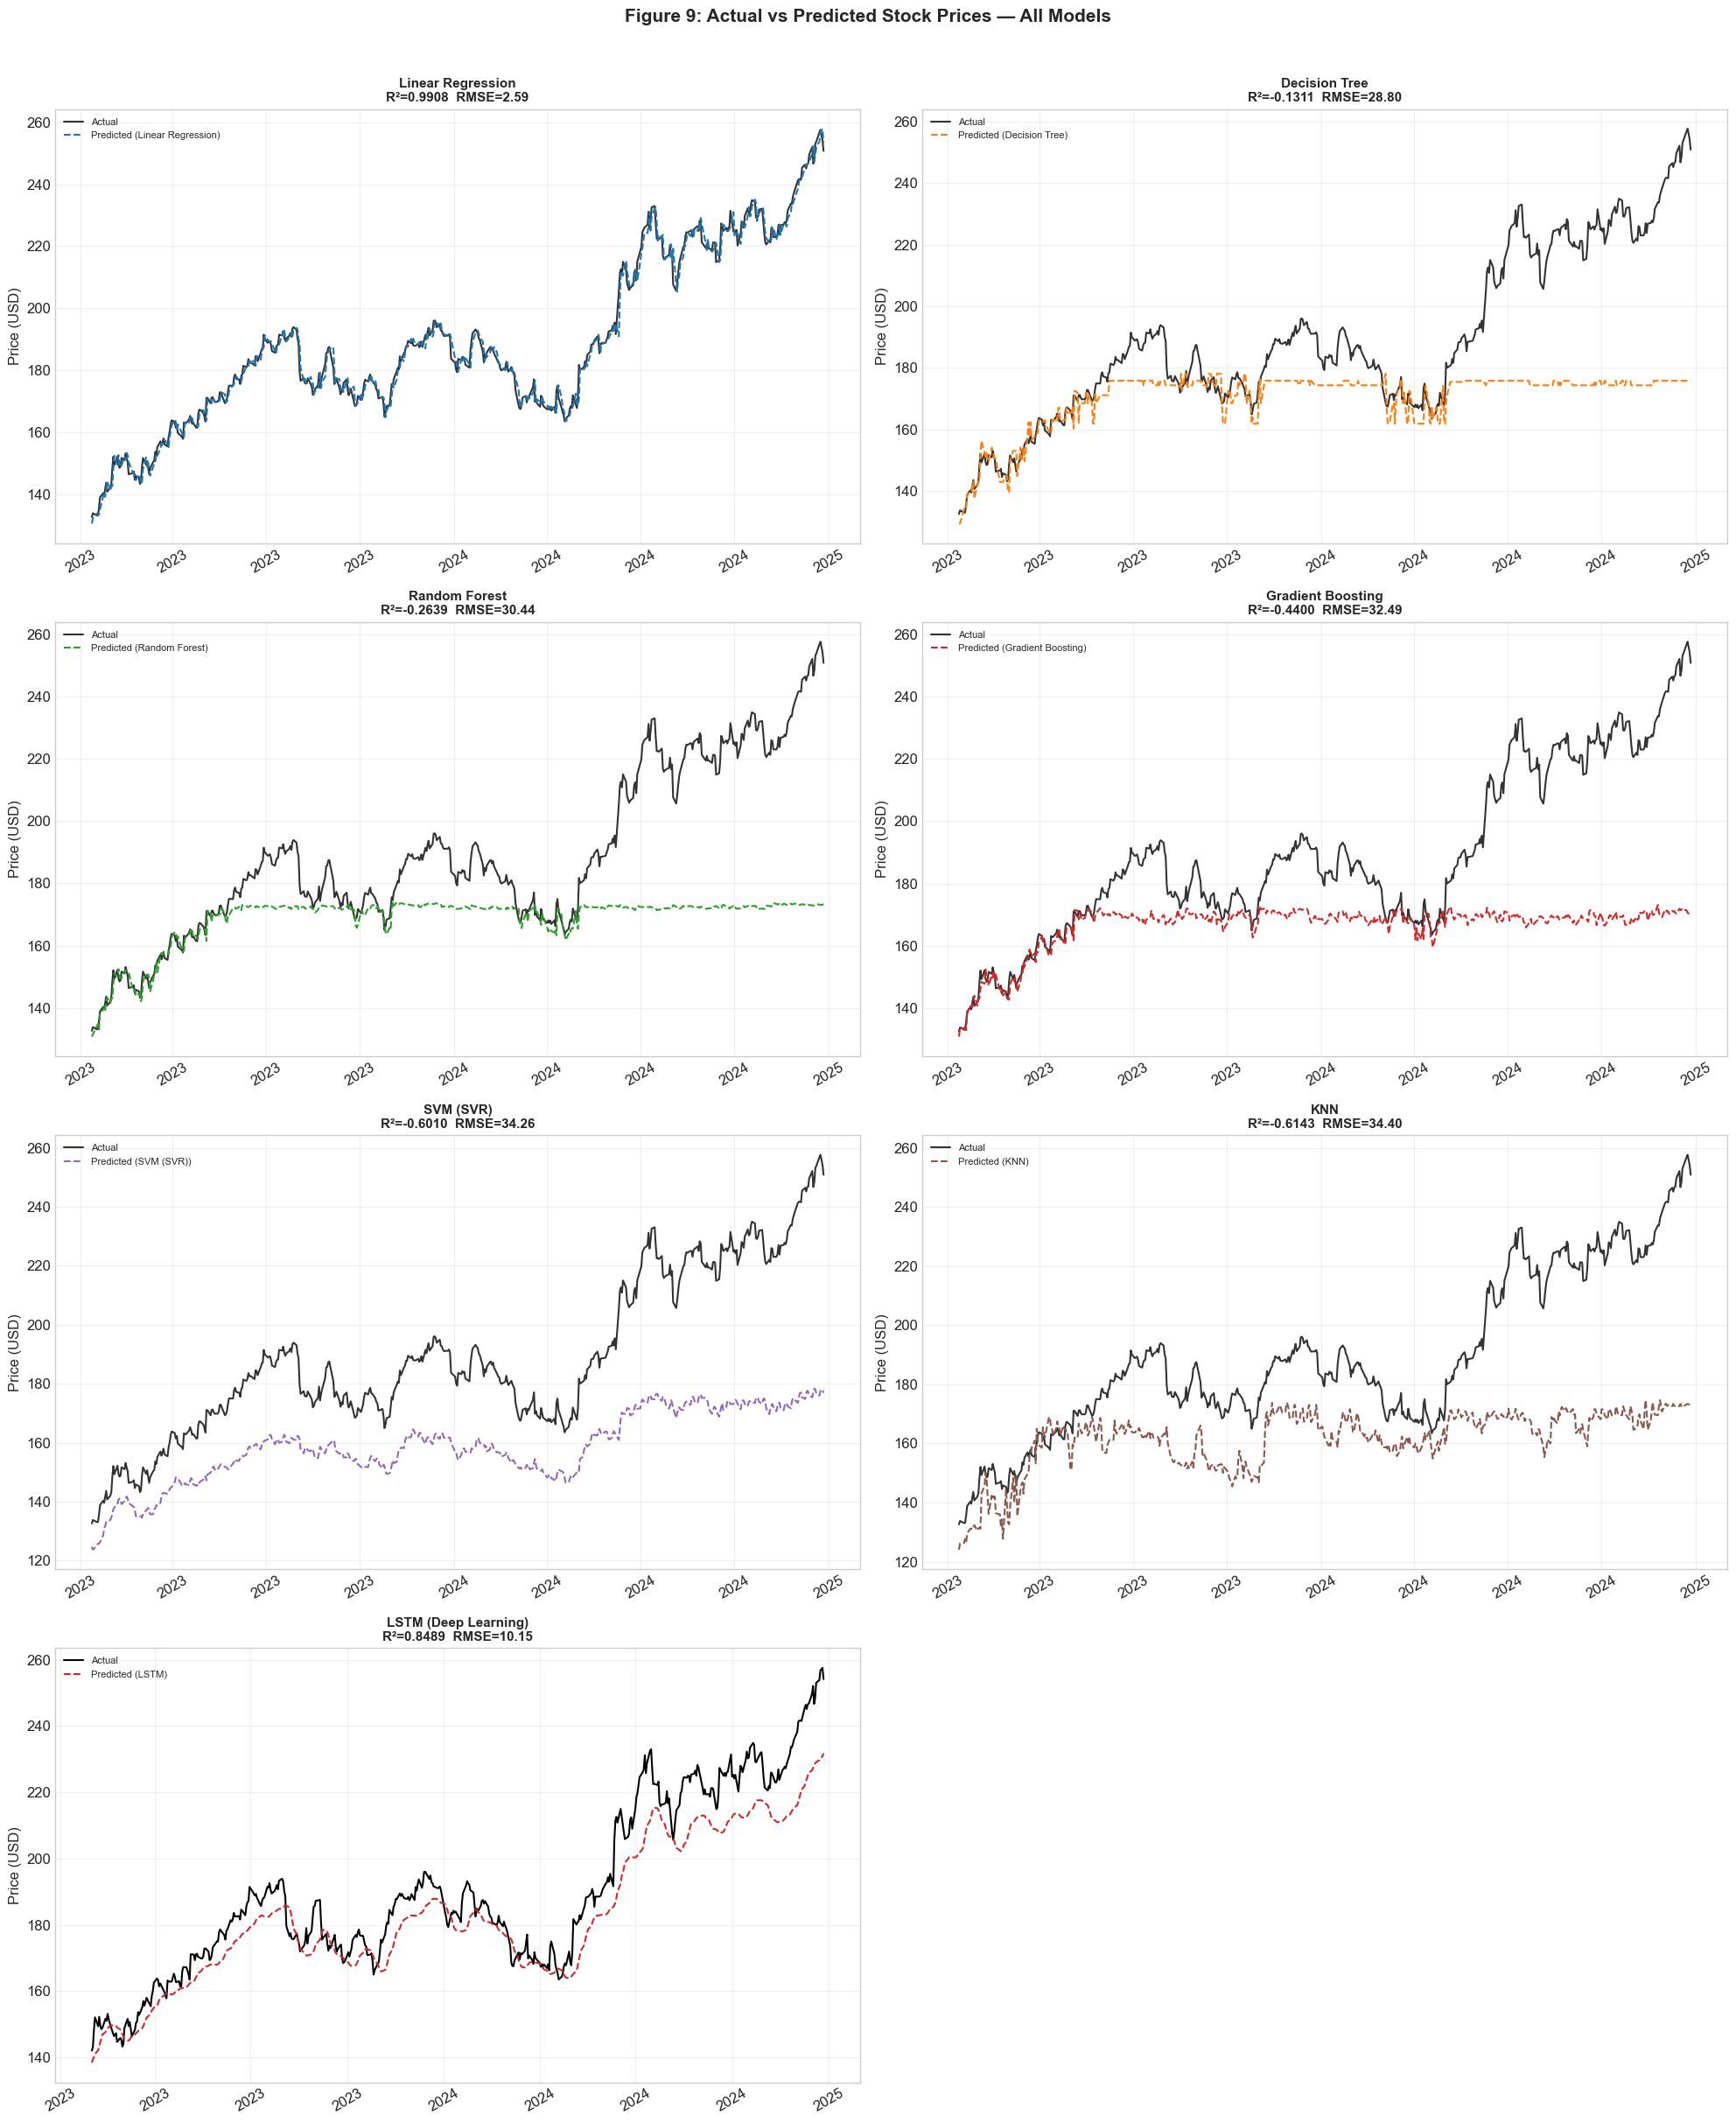

Figure 9 saved.


In [25]:
# Figure 9: Prediction vs Actual — all ML models + LSTM
# Use common test dates (last 20% of chronological data)
n_test = len(X_test)
test_dates = df_fe['Date'].values[-n_test:]

fig, axes = plt.subplots(4, 2, figsize=(20, 24))
axes = axes.flatten()

model_names = list(ml_results.keys())
for i, name in enumerate(model_names):
    y_true = ml_results[name]['y_true']
    y_pred = ml_results[name]['y_pred']
    axes[i].plot(test_dates, y_true, label='Actual', color='black', linewidth=1.5, alpha=0.8)
    axes[i].plot(test_dates, y_pred, label=f'Predicted ({name})', linewidth=1.5, linestyle='--', color=colors[i])
    axes[i].set_title(f'{name}\nR²={ml_results[name]["R2"]:.4f}  RMSE={ml_results[name]["RMSE"]:.2f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend(fontsize=8)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(axes[i].xaxis.get_majorticklabels(), rotation=30)

# LSTM subplot
lstm_dates = df_fe['Date'].values[LOOKBACK + split_lstm:]
min_len = min(len(lstm_dates), len(y_lstm_true_orig))
axes[6].plot(lstm_dates[:min_len], y_lstm_true_orig[:min_len], label='Actual', color='black', linewidth=1.5)
axes[6].plot(lstm_dates[:min_len], y_lstm_pred_orig[:min_len], label='Predicted (LSTM)', color='#d62728', linewidth=1.5, linestyle='--')
axes[6].set_title(f'LSTM (Deep Learning)\nR²={lstm_r2:.4f}  RMSE={lstm_rmse:.2f}', fontsize=11, fontweight='bold')
axes[6].set_ylabel('Price (USD)')
axes[6].legend(fontsize=8)
axes[6].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(axes[6].xaxis.get_majorticklabels(), rotation=30)

axes[7].axis('off')

fig.suptitle('Figure 9: Actual vs Predicted Stock Prices — All Models', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig9_all_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 9 saved.")

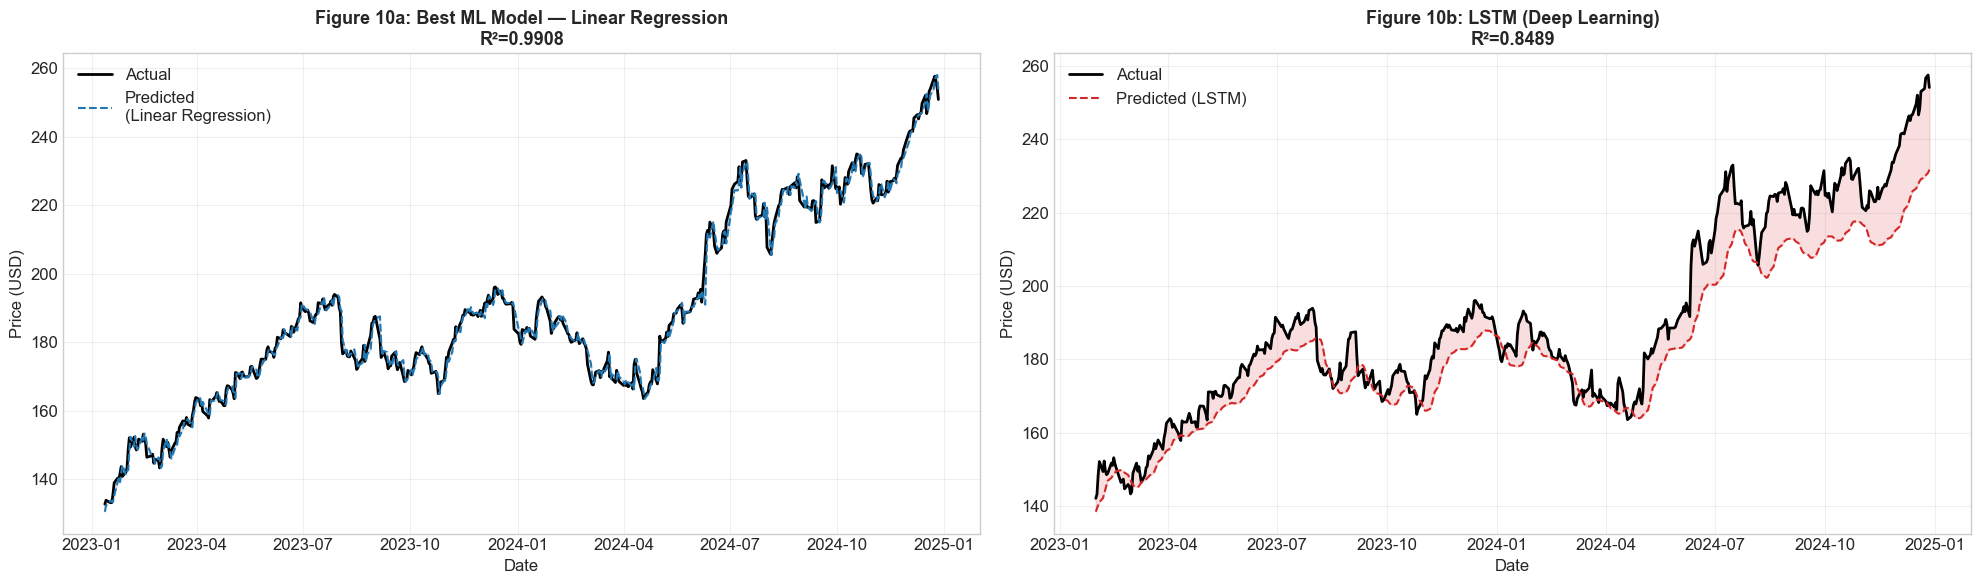

Figure 10 saved.


In [26]:
# Figure 10: Best ML vs LSTM Head-to-Head
best_ml_name = results_df[results_df['Type']=='ML'].iloc[0]['Model']
best_ml_true = ml_results[best_ml_name]['y_true']
best_ml_pred = ml_results[best_ml_name]['y_pred']
best_ml_dates = test_dates

lstm_dates_plot = df_fe['Date'].values[LOOKBACK + split_lstm:]
min_len = min(len(lstm_dates_plot), len(y_lstm_true_orig))

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Best ML
axes[0].plot(best_ml_dates, best_ml_true, label='Actual', color='black', linewidth=2)
axes[0].plot(best_ml_dates, best_ml_pred, label=f'Predicted\n({best_ml_name})',
             color='#1f77b4', linewidth=1.5, linestyle='--')
axes[0].fill_between(best_ml_dates, best_ml_true, best_ml_pred, alpha=0.15, color='#1f77b4')
axes[0].set_title(f'Figure 10a: Best ML Model — {best_ml_name}\nR²={results_df[results_df["Model"]==best_ml_name]["R²"].values[0]:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].set_xlabel('Date')
axes[0].legend()

# LSTM
axes[1].plot(lstm_dates_plot[:min_len], y_lstm_true_orig[:min_len], label='Actual', color='black', linewidth=2)
axes[1].plot(lstm_dates_plot[:min_len], y_lstm_pred_orig[:min_len], label='Predicted (LSTM)',
             color='#d62728', linewidth=1.5, linestyle='--')
axes[1].fill_between(lstm_dates_plot[:min_len], y_lstm_true_orig[:min_len], y_lstm_pred_orig[:min_len],
                     alpha=0.15, color='#d62728')
axes[1].set_title(f'Figure 10b: LSTM (Deep Learning)\nR²={lstm_r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price (USD)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig10_best_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 10 saved.")

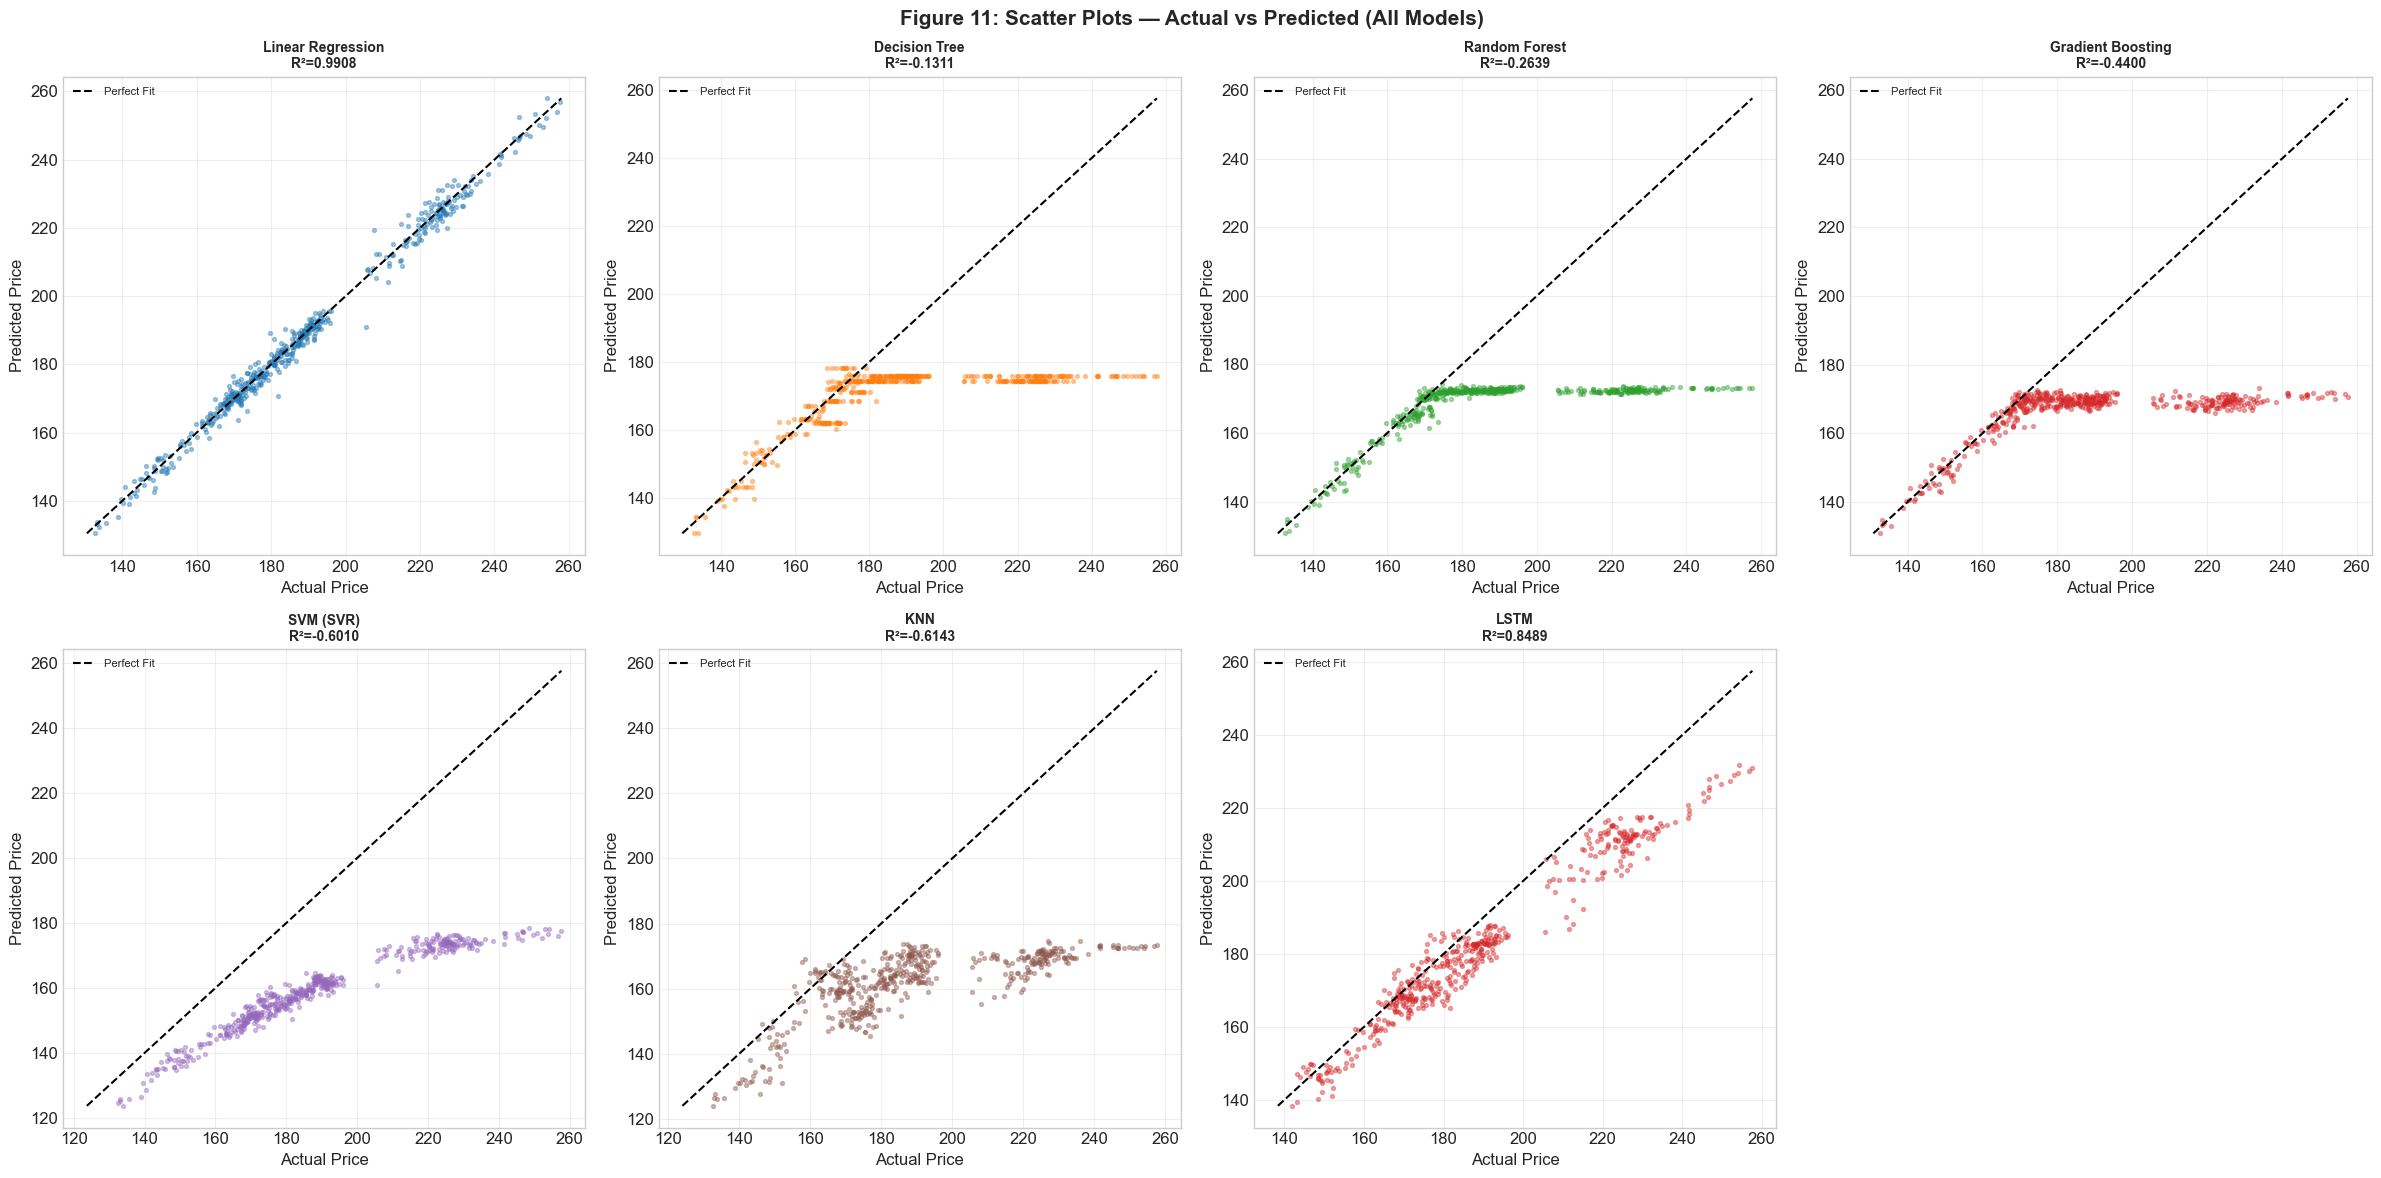

Figure 11 saved.


In [27]:
# Figure 11: Scatter Plot — Predicted vs Actual
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, name in enumerate(model_names):
    y_true = ml_results[name]['y_true']
    y_pred = ml_results[name]['y_pred']
    axes[i].scatter(y_true, y_pred, alpha=0.4, color=colors[i], s=8)
    min_val, max_val = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    axes[i].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Fit')
    axes[i].set_title(f'{name}\nR²={ml_results[name]["R2"]:.4f}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')
    axes[i].legend(fontsize=8)

# LSTM scatter
axes[6].scatter(y_lstm_true_orig, y_lstm_pred_orig, alpha=0.4, color='#d62728', s=8)
min_val = min(y_lstm_true_orig.min(), y_lstm_pred_orig.min())
max_val = max(y_lstm_true_orig.max(), y_lstm_pred_orig.max())
axes[6].plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5, label='Perfect Fit')
axes[6].set_title(f'LSTM\nR²={lstm_r2:.4f}', fontsize=10, fontweight='bold')
axes[6].set_xlabel('Actual Price')
axes[6].set_ylabel('Predicted Price')
axes[6].legend(fontsize=8)

axes[7].axis('off')

fig.suptitle('Figure 11: Scatter Plots — Actual vs Predicted (All Models)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 11 saved.")

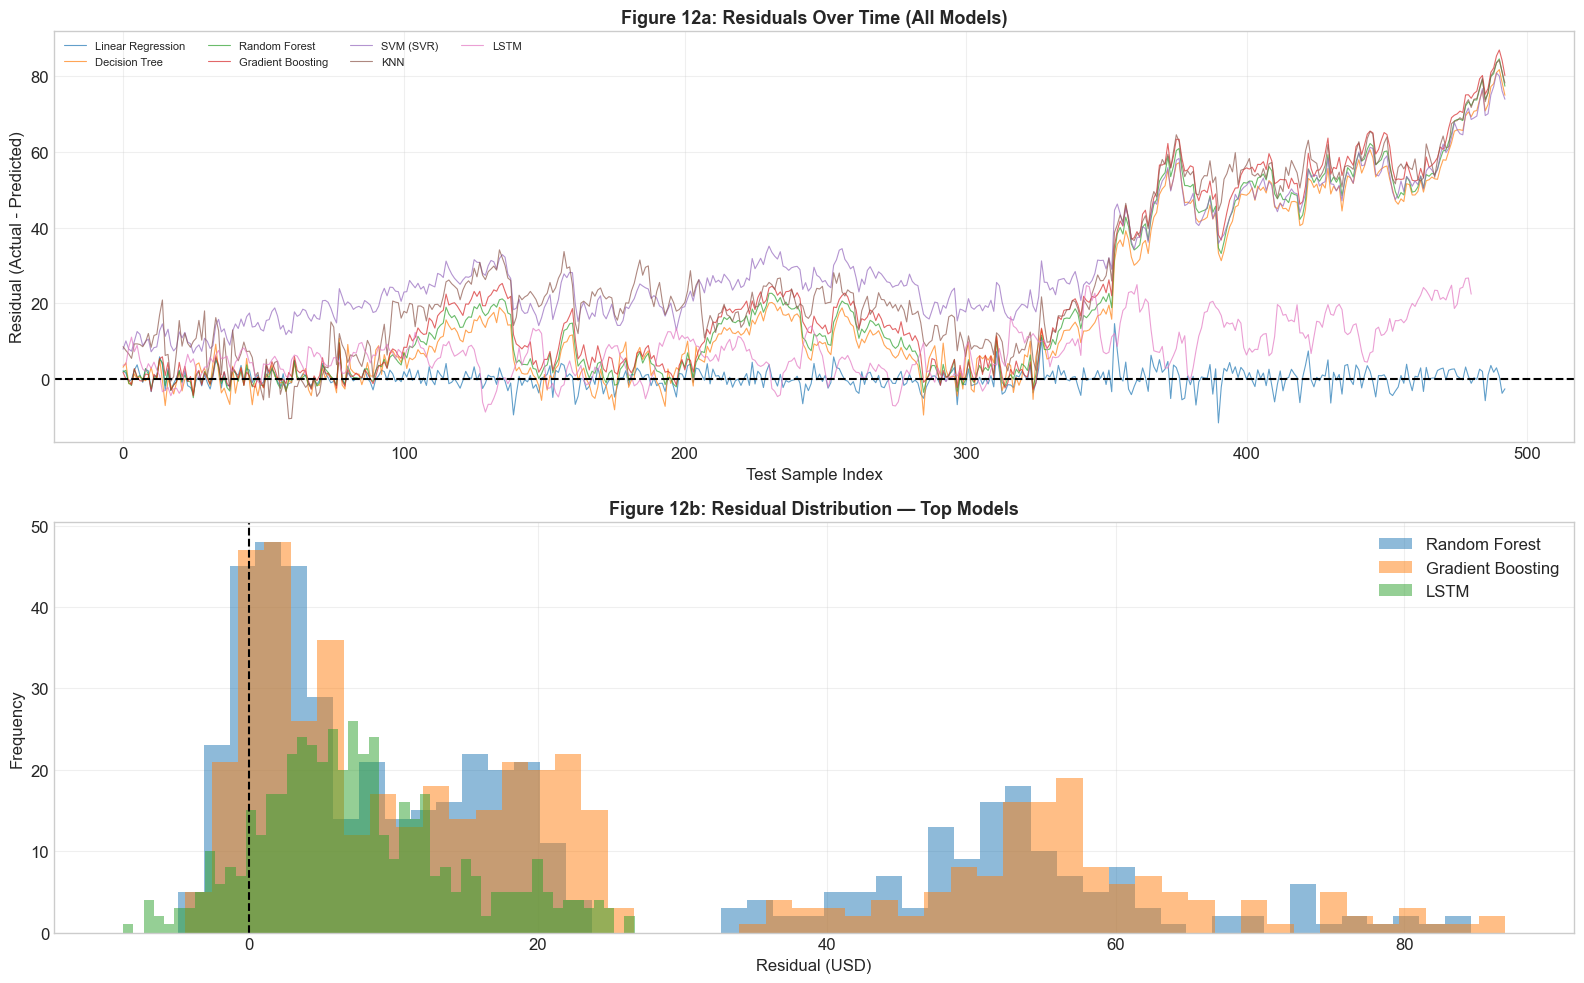

Figure 12 saved.


In [28]:
# Figure 12: Residuals Analysis
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for i, name in enumerate(list(ml_results.keys()) + ['LSTM']):
    if name == 'LSTM':
        residuals = y_lstm_true_orig[:len(y_lstm_pred_orig)] - y_lstm_pred_orig
    else:
        residuals = ml_results[name]['y_true'] - ml_results[name]['y_pred']
    axes[0].plot(residuals, label=name, alpha=0.7, linewidth=0.8)

axes[0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[0].set_title('Figure 12a: Residuals Over Time (All Models)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Test Sample Index')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].legend(ncol=4, fontsize=8)

# Residuals Distribution
for i, name in enumerate(['Random Forest', 'Gradient Boosting', 'LSTM']):
    if name == 'LSTM':
        residuals = y_lstm_true_orig[:len(y_lstm_pred_orig)] - y_lstm_pred_orig
    else:
        residuals = ml_results[name]['y_true'] - ml_results[name]['y_pred']
    axes[1].hist(residuals, bins=50, alpha=0.5, label=name, edgecolor='none')

axes[1].axvline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_title('Figure 12b: Residual Distribution — Top Models', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig12_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 12 saved.")

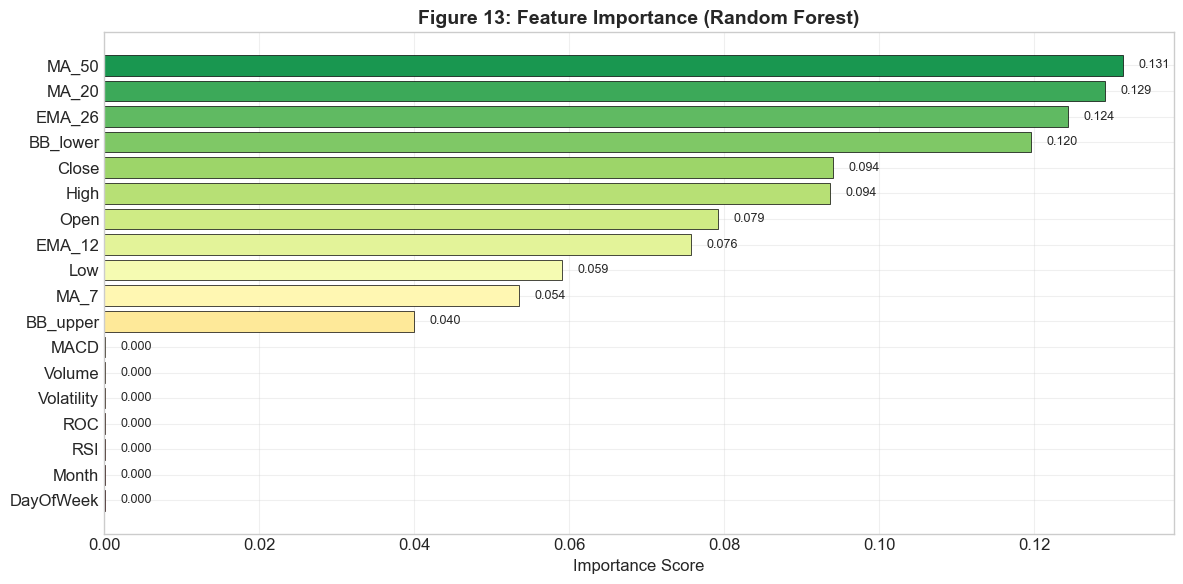

Figure 13 saved.


In [29]:
# Figure 13: Feature Importance (Random Forest)
rf_model = ml_models['Random Forest']
importances = rf_model.feature_importances_
feat_imp = pd.Series(importances, index=ML_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
colors_fi = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(feat_imp)))
bars = ax.barh(feat_imp.index[::-1], feat_imp.values[::-1], color=colors_fi[::-1], edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, feat_imp.values[::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Figure 13: Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('fig13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 13 saved.")

In [30]:
# Final Summary Table
print("\n" + "="*75)
print(" FINAL COMPARATIVE PERFORMANCE SUMMARY — STOCK PRICE PREDICTION (AAPL)")
print("="*75)
print(f"{'Rank':<5} {'Model':<28} {'Type':<6} {'MAE':>7} {'RMSE':>7} {'R²':>8} {'MAPE(%)':>9}")
print("-"*75)
for rank, row in results_df.iterrows():
    print(f"{rank:<5} {row['Model']:<28} {row['Type']:<6} {row['MAE']:>7.2f} {row['RMSE']:>7.2f} {row['R²']:>8.4f} {row['MAPE(%)']:>9.2f}")
print("="*75)
best = results_df.iloc[0]
print(f"\n🏆 Best Model: {best['Model']} (R²={best['R²']:.4f}, RMSE={best['RMSE']:.2f})")


 FINAL COMPARATIVE PERFORMANCE SUMMARY — STOCK PRICE PREDICTION (AAPL)
Rank  Model                        Type       MAE    RMSE       R²   MAPE(%)
---------------------------------------------------------------------------
1     Linear Regression            ML        1.91    2.59   0.9908      1.02
2     LSTM                         DL        8.12   10.15   0.8489      4.03
3     Decision Tree                ML       19.42   28.80  -0.1311      9.07
4     Random Forest                ML       20.65   30.44  -0.2639      9.63
5     Gradient Boosting            ML       22.75   32.49  -0.4400     10.68
6     SVM (SVR)                    ML       30.28   34.26  -0.6010     15.22
7     KNN                          ML       27.69   34.40  -0.6143     13.57

🏆 Best Model: Linear Regression (R²=0.9908, RMSE=2.59)


## 9. Multi-Split Evaluation (70:30, 80:20, 90:10)

In [31]:
# Evaluate top 3 ML models + LSTM across different splits
top_models_names = ['Random Forest', 'Gradient Boosting', 'Linear Regression']
splits = [0.70, 0.80, 0.90]
split_labels = ['70:30', '80:20', '90:10']

split_results = []
print("Multi-split evaluation...\n")

for split_ratio, split_label in zip(splits, split_labels):
    split_idx_s = int(len(X_scaled) * split_ratio)
    X_tr, X_te = X_scaled[:split_idx_s], X_scaled[split_idx_s:]
    y_tr, y_te = y_scaled[:split_idx_s], y_scaled[split_idx_s:]

    for mname in top_models_names:
        model_s = ml_models[mname]
        model_s.fit(X_tr, y_tr)
        y_pred_s = model_s.predict(X_te)
        y_true_orig_s = scaler_y.inverse_transform(y_te.reshape(-1,1)).ravel()
        y_pred_orig_s = scaler_y.inverse_transform(y_pred_s.reshape(-1,1)).ravel()
        mae_s  = mean_absolute_error(y_true_orig_s, y_pred_orig_s)
        rmse_s = np.sqrt(mean_squared_error(y_true_orig_s, y_pred_orig_s))
        r2_s   = r2_score(y_true_orig_s, y_pred_orig_s)
        split_results.append({'Split': split_label, 'Model': mname,
                               'MAE': round(mae_s,2), 'RMSE': round(rmse_s,2), 'R²': round(r2_s,4)})

    # LSTM for each split
    split_lstm_idx = int(len(X_seq) * split_ratio)
    Xl_tr, Xl_te = X_seq[:split_lstm_idx], X_seq[split_lstm_idx:]
    yl_tr, yl_te = y_seq[:split_lstm_idx], y_seq[split_lstm_idx:]
    lstm_s = Sequential([
        Input(shape=(LOOKBACK, 1)),
        LSTM(64, return_sequences=True), Dropout(0.2),
        LSTM(32), Dropout(0.2),
        Dense(1)
    ])
    lstm_s.compile(optimizer='adam', loss='mse')
    lstm_s.fit(Xl_tr, yl_tr, epochs=30, batch_size=32, verbose=0,
               callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
    yl_pred = lstm_s.predict(Xl_te, verbose=0).ravel()
    yl_true_orig = scaler_lstm.inverse_transform(yl_te.reshape(-1,1)).ravel()
    yl_pred_orig = scaler_lstm.inverse_transform(yl_pred.reshape(-1,1)).ravel()
    split_results.append({'Split': split_label, 'Model': 'LSTM',
                           'MAE': round(mean_absolute_error(yl_true_orig,yl_pred_orig),2),
                           'RMSE': round(np.sqrt(mean_squared_error(yl_true_orig,yl_pred_orig)),2),
                           'R²': round(r2_score(yl_true_orig,yl_pred_orig),4)})
    print(f"  Split {split_label} done.")

split_df = pd.DataFrame(split_results)
print("\n=== MULTI-SPLIT RESULTS ===")
print(split_df.to_string(index=False))

Multi-split evaluation...

  Split 70:30 done.
  Split 80:20 done.
  Split 90:10 done.

=== MULTI-SPLIT RESULTS ===
Split             Model   MAE  RMSE      R²
70:30     Random Forest 14.35 24.27  0.3269
70:30 Gradient Boosting 15.29 25.33  0.2669
70:30 Linear Regression  2.18  2.89  0.9904
70:30              LSTM  6.02  7.41  0.9380
80:20     Random Forest 20.65 30.44 -0.2639
80:20 Gradient Boosting 22.75 32.49 -0.4400
80:20 Linear Regression  1.91  2.59  0.9908
80:20              LSTM  9.25 10.68  0.8328
90:10     Random Forest 20.09 26.94 -0.1211
90:10 Gradient Boosting 23.40 30.89 -0.4736
90:10 Linear Regression  2.12  2.90  0.9870
90:10              LSTM  5.71  7.08  0.9223


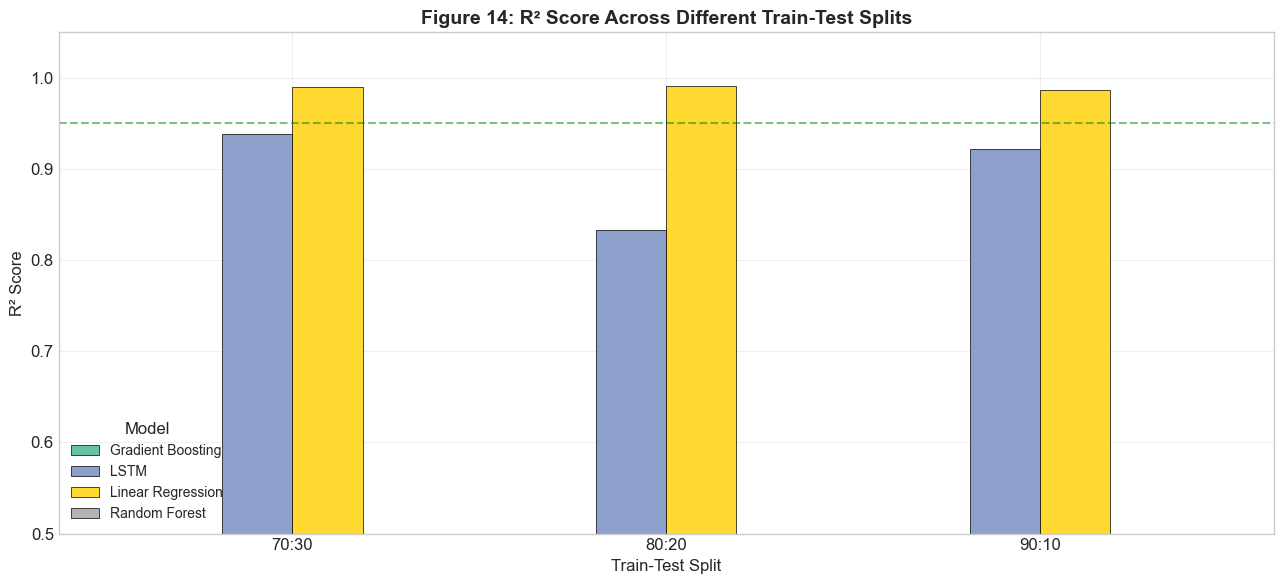

Figure 14 saved.


In [32]:
# Figure 14: Multi-Split R² Comparison
fig, ax = plt.subplots(figsize=(13, 6))
pivot_r2 = split_df.pivot(index='Split', columns='Model', values='R²')
pivot_r2.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5, width=0.75)
ax.set_title('Figure 14: R² Score Across Different Train-Test Splits', fontsize=14, fontweight='bold')
ax.set_xlabel('Train-Test Split')
ax.set_ylabel('R² Score')
ax.set_xticklabels(pivot_r2.index, rotation=0)
ax.legend(title='Model', fontsize=10)
ax.set_ylim(0.5, 1.05)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.5, label='Excellent (0.95)')
plt.tight_layout()
plt.savefig('fig14_multisplit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 14 saved.")

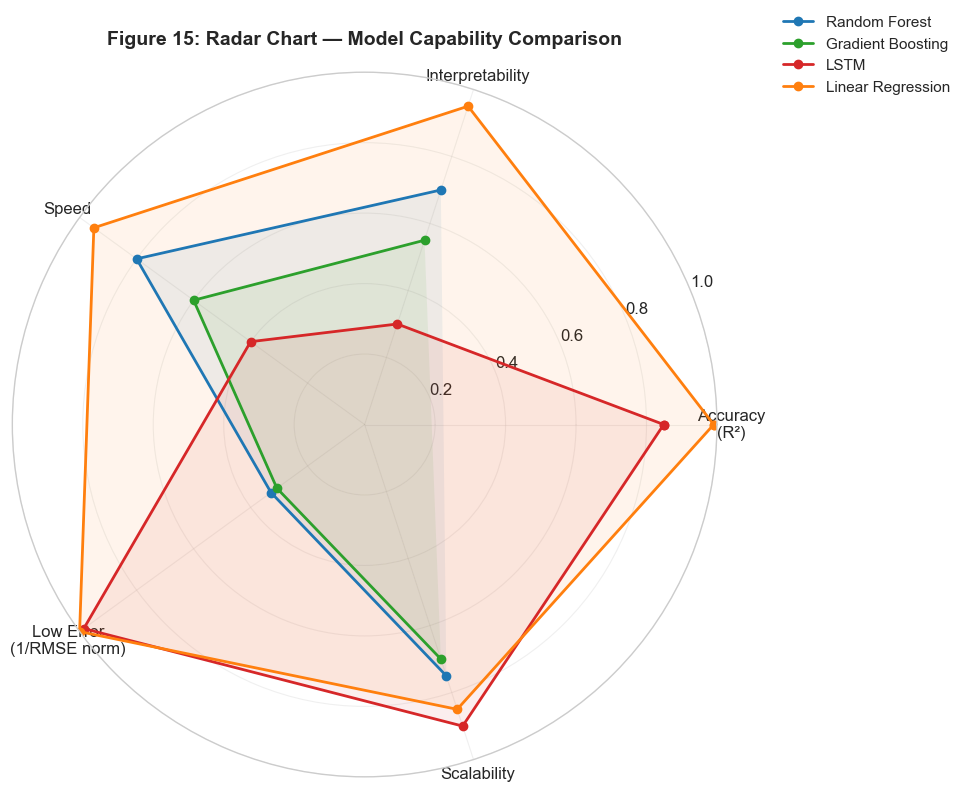

Figure 15 saved.


In [33]:
# Figure 15: Radar Chart — Model Capabilities
from matplotlib.patches import FancyArrowPatch

categories = ['Accuracy\n(R²)', 'Interpretability', 'Speed', 'Low Error\n(1/RMSE norm)', 'Scalability']
N = len(categories)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

# Scores (0–1 normalized, subjective + metric-based)
r2_norm = lambda r2: min(r2, 1.0)
# Random Forest
rf_r2 = results_df[results_df['Model']=='Random Forest']['R²'].values[0]
rf_rmse = results_df[results_df['Model']=='Random Forest']['RMSE'].values[0]

model_scores = {
    'Random Forest':     [r2_norm(rf_r2), 0.70, 0.80, min(1/rf_rmse*10, 1), 0.75],
    'Gradient Boosting': [r2_norm(results_df[results_df['Model']=='Gradient Boosting']['R²'].values[0]),
                          0.55, 0.60, min(1/results_df[results_df['Model']=='Gradient Boosting']['RMSE'].values[0]*10,1), 0.70],
    'LSTM':              [r2_norm(lstm_r2), 0.30, 0.40, min(1/lstm_rmse*10,1), 0.90],
    'Linear Regression': [r2_norm(results_df[results_df['Model']=='Linear Regression']['R²'].values[0]),
                          0.95, 0.95, min(1/results_df[results_df['Model']=='Linear Regression']['RMSE'].values[0]*10,1), 0.85],
}

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
radar_colors = ['#1f77b4','#2ca02c','#d62728','#ff7f0e']

for idx, (mname, scores) in enumerate(model_scores.items()):
    vals = scores + scores[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, color=radar_colors[idx], label=mname)
    ax.fill(angles, vals, alpha=0.08, color=radar_colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_title('Figure 15: Radar Chart — Model Capability Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=11)

plt.tight_layout()
plt.savefig('fig15_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure 15 saved.")

In [34]:
print("\n" + "="*60)
print("✅ ALL FIGURES GENERATED AND SAVED:")
print("="*60)
figures = [
    'fig1_stock_history.png     — Stock price & volume history',
    'fig3_eda.png               — Correlation heatmap & price distribution',
    'fig5_technical_indicators.png — MA, RSI, MACD',
    'fig6_lstm_training.png     — LSTM training curves',
    'fig7_metric_comparison.png — MAE/RMSE/MAPE bar charts',
    'fig8_r2_comparison.png     — R² horizontal bar chart',
    'fig9_all_predictions.png   — All model predictions',
    'fig10_best_comparison.png  — Best ML vs LSTM head-to-head',
    'fig11_scatter_plots.png    — Scatter plots all models',
    'fig12_residuals.png        — Residual analysis',
    'fig13_feature_importance.png — RF feature importance',
    'fig14_multisplit.png       — Multi-split R² comparison',
    'fig15_radar.png            — Radar capability chart',
]
for f in figures:
    print(f"  📊 {f}")
print("\n✅ Notebook complete! Use these results for the research paper.")


✅ ALL FIGURES GENERATED AND SAVED:
  📊 fig1_stock_history.png     — Stock price & volume history
  📊 fig3_eda.png               — Correlation heatmap & price distribution
  📊 fig5_technical_indicators.png — MA, RSI, MACD
  📊 fig6_lstm_training.png     — LSTM training curves
  📊 fig7_metric_comparison.png — MAE/RMSE/MAPE bar charts
  📊 fig8_r2_comparison.png     — R² horizontal bar chart
  📊 fig9_all_predictions.png   — All model predictions
  📊 fig10_best_comparison.png  — Best ML vs LSTM head-to-head
  📊 fig11_scatter_plots.png    — Scatter plots all models
  📊 fig12_residuals.png        — Residual analysis
  📊 fig13_feature_importance.png — RF feature importance
  📊 fig14_multisplit.png       — Multi-split R² comparison
  📊 fig15_radar.png            — Radar capability chart

✅ Notebook complete! Use these results for the research paper.
